In [1]:
import math
import random
import torch
import time
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data=data
        self.grad=0.0
        self._backward= lambda: None
        self._prev=set(_children)
        self._op=_op
        self.label=label
        
    def __repr__(self):
        return f"Value(data = {self.data})"
        
    def __add__(self, other):
        other=other if isinstance (other, Value) else Value(other)
        out=Value(self.data+other.data, (self, other),'+')

        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        out._backward=_backward
        
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def __neg__(self): 
        return self * -1

    def __sub__(self, other):
        return self+(-other)
    
    def __mul__(self, other):
        other=other if isinstance (other, Value) else Value(other)
        out=Value(self.data*other.data, (self, other),'*')
        
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        
        return out
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __rmul__(self, other):
        return self*other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def log(self):
        out=Value(math.log(self.data), (self, ), "log")

        def _backward():
            self.grad+=(1/self.data)*out.grad
        out._backward=_backward

        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'e^x')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad=1.0

        for node in reversed(topo):
            node._backward()

    #Activation Functions
    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t, (self,), 'tanh')

        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward

        return out

    def sigmoid(self):
        x=self.data
        sig=1/(1+(math.exp(-x)))
        out=Value(sig, (self,), 'sigmoid')

        def _backward():
            self.grad+=(sig*(1-sig))*out.grad
        out._backward=_backward

        return out

    def leakyReLU(self):
        out=Value(0.01*x if self.data<=0 else self.data, (self,), 'leaky ReLU')

        def _backward():
            self.grad+=(0.01 if self.data<0 else 1)*out.grad
        out._backward=_backward

        return out
    
    def ReLU(self):
        out=Value(0 if self.data<=0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad+=(self.data>0)*out.grad
        out._backward=_backward

        return out

In [3]:
def trace(root):
    nodes, edges=set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

In [4]:
#Graphviz API
from graphviz import Digraph
def draw_dot(root):
    dot=Digraph(format='svg', graph_attr={'rankdir':'LR'})
    nodes, edges=trace(root)

    for n in nodes:
        uid=str(id(n))
        dot.node(name=uid, label="%s | {data %.4f} | {grad %.4f}" % (n.label, n.data, n.grad), shape='record')

        
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)
        

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    return dot

In [5]:
#Copied Code beyond this point: 
class Neuron:
    def __init__(self, nin):
        self.w=[Value(random.uniform(-1,1), label=f'w{i}') for i in range(nin)] 
        self.b=Value(random.uniform(-1,1), label='b')

    def __call__(self, x):
        #w*x+b
        act=sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        #out=act.ReLU()
        out=act
        return out

    def parameters(self):
        return self.w+[self.b]
class Layer:
    def __init__(self, nin, nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs=[n(x) for n in self.neurons]
        #return outs[0] if len(outs)==1 else outs
        return outs

    def parameters(self):
        params=[]
        for neuron in self.neurons:
            ps=neuron.parameters()
            params.extend(ps)
        return params
class MLP: 
    def __init__(self, nin, nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i], sz[i+1]) for i in range(len(nouts))] #calls Layer.__init__
    def __call__(self, x):
        for i,layer in enumerate(self.layers):
            x=layer(x) #calls Layer.__call__
            
            if i!=len(self.layers)-1:
                x=[v.ReLU() for v in x]
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [69]:
n=MLP(64, [16, 10]) #3 inputs, 2 layers of 4 neurons each[4,4], 1 output neuron

In [70]:
from sklearn.datasets import load_digits
data=load_digits()
x=data.data
y=data.target

print(data.data.shape)
print(data.target.shape)

from sklearn.preprocessing import StandardScaler
X = np.array(x)
X = StandardScaler().fit_transform(X)
x = X.tolist()

print(x[:1])
print(y[:1])
print(type(x), type(y))

(1797, 64)
(1797,)
[[0.0, -0.3350164872543856, -0.04308101770538793, 0.2740715207154218, -0.6644775126361527, -0.8441293865949171, -0.40972392088346243, -0.1250229232970408, -0.05907755711884675, -0.6240092623290964, 0.4829744992519545, 0.7596224512649244, -0.05842586308220443, 1.1277211297338117, 0.8795830595483867, -0.13043338063115095, -0.04462507326885248, 0.11144272449970435, 0.8958804382797294, -0.8606663175537699, -1.1496484601880896, 0.5154718747277965, 1.905963466976408, -0.11422184388584329, -0.03337972630405602, 0.48648927722411006, 0.46988512333994237, -1.4999013596489101, -1.6140627717776248, 0.07639777342245602, 1.541814131110763, -0.047232382286089766, 0.0, 0.7646555295175514, 0.0526301875348861, -1.4476300608538812, -1.7366644253170966, 0.04361587747126204, 1.4395580374572254, 0.0, -0.061343668908253476, 0.8105536026095989, 0.6301171415641497, -1.1224571135882688, -1.0662315782633949, 0.6609647521402978, 0.8184507612621287, -0.08874161717060432, -0.035433262605025426, 0

In [20]:
def softmax(logits):
    max_val = max(logits, key=lambda v: v.data)
    shifted = [x - max_val for x in logits]
    exps = [x.exp() for x in shifted]
    
    sum_exp = exps[0]
    for e in exps[1:]:
        sum_exp = sum_exp + e

    return [e / sum_exp for e in exps]


def nll_loss(ypred_logits, y_true):
    probs=softmax(ypred_logits)
    loss=-(probs[y_true]).log()
    return loss

In [21]:
def test_train_split(x, y, test_size, shuffle=True, random_state=42): 

    np.random.seed(random_state)

    x = np.array(x)
    y= np.array(y)

    index=np.arange(len(x))

    if shuffle==True:
        np.random.shuffle(index)

    z=int(test_size*len(x)) #assuming it'll be a float in [0,1] for now

    train_index=index[z:]
    test_index=index[:z]
    x_train=x[train_index]
    x_test=x[test_index]
    y_train=y[train_index]
    y_test=y[test_index]
    return x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test = test_train_split(x, y, test_size=0.2)
print("X Train: ", len(x_train))
print("X Test: ", len(x_test))
print("Y Train: ", len(y_train))
print("Y Test: ", len(y_test))

X Train:  1438
X Test:  359
Y Train:  1438
Y Test:  359


In [22]:
def loss_plot(losses):
    plt.plot(losses)
    plt.show

In [28]:
#Training loop
def loss_accumulation_train(epoch, xs, ys, n):
    losses=[]
    epoch_timings=[]
    for k in range(epoch):
        start=time.time()
        
        #forward pass
        ypred=[n(x) for x in xs]
        loss=sum((yout[0]-ygt)**2 for ygt, yout in zip(ys, ypred))
        losses.append(loss.data)
        
        #backward pass
        for p in n.parameters():
            p.grad=0.0 #zero_grad()
        loss.backward()
    
        #update
        for p in n.parameters():
            p.data+=-0.01 * p.grad
        end=time.time()

        duration=end-start
        epoch_timings.append(duration)
        print(f"Epoch: {k} | Loss: {loss.data} | Duration: {duration: .4f}s")
    
    loss_plot(losses)
    print(ypred)
    return loss, ypred

In [23]:
def predict(x):

    logits = n(x) #Single forward pass

    values = [v.data for v in logits] #outputs as numbers, not Values

    pred_class = values.index(max(values)) #max value is prediction

    return pred_class #returns the index of the prediction with the maximum likelihood

class_names = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

#true_class = y_test[0]
#pred_class = predict(x_test[0])

#print("True:", class_names[true_class])
#print("Predicted:", class_names[pred_class])

In [24]:
def accuracy(xs, ys):
    correct=0
    for x, y in zip(xs, ys):
        pred=predict(x)
        if pred==y:
            correct+=1
    return correct/len(xs)

#accuracy(x_train, y_train)

In [71]:
def mini_batch_training(xs, ys, n_epoch, n, mini_batch_size):
    losses = []
    epoch_timings = []

    x = np.array(xs) #numpy array
    y = np.array(ys) #numpy array
    
    for epoch in range(n_epoch):
        start = time.time()

        #shuffle indices
        index=np.arange(len(xs)) #index matching 
        np.random.shuffle(index) #random shuffling of indices
        
        #applying randomly shuffled indices
        x_shuffled=x[index]  
        y_shuffled=y[index] 
        epoch_loss=0.0
        
        for i in range(0, len(xs), mini_batch_size):
            #if(i+mini_batch_size<len(x)):
                #x_mini_batch=x_shuffled[i:i+mini_batch_size]
                #y_mini_batch=y_shuffled[i:i+mini_batch_size]
            #else:
                #x_mini_batch=x_shuffled[i:]
                #y_mini_batch=y_shuffled[i:]
            x_mini_batch=x_shuffled[i:i+mini_batch_size]
            y_mini_batch=y_shuffled[i:i+mini_batch_size]
            
            #zero_grad 
            for p in n.parameters():
                p.grad = 0.0
    
            batch_loss = Value(0.0)

            #loop for each sample
            for x_sample, ygt_idx in zip(x_mini_batch, y_mini_batch):
                #forward pass
                ypred_logits = n(x_sample)
    
                #backward pass
                l = nll_loss(ypred_logits, ygt_idx)                           
                batch_loss = batch_loss + l

            batch_loss.backward() 
        
            # update
            for p in n.parameters():
                p.grad = max(min(p.grad, 1.0), -1.0)  # clip grads
                p.data += -0.01 * p.grad

            epoch_loss += batch_loss.data
            print(f"Batch: {i // mini_batch_size + 1} | Batch Loss: {batch_loss.data:.4f}")

        end = time.time()
        duration = end - start
        epoch_timings.append(duration)

        print(f"Epoch: {epoch} | Epoch Loss: {epoch_loss:.4f} | Duration: {duration:.4f}s")
        losses.append(epoch_loss)  

        #Early Stopping
        acc=accuracy(x_test, y_test)
        print(f"Accuracy: {acc}")
        if acc>0.95:
            break

    loss_plot(losses)
    return epoch_loss

Batch: 1 | Batch Loss: 391.7709
Batch: 2 | Batch Loss: 236.1754
Batch: 3 | Batch Loss: 280.6574
Batch: 4 | Batch Loss: 193.2898
Batch: 5 | Batch Loss: 178.5376
Batch: 6 | Batch Loss: 198.6677
Batch: 7 | Batch Loss: 153.4911
Batch: 8 | Batch Loss: 214.5615
Batch: 9 | Batch Loss: 130.1698
Batch: 10 | Batch Loss: 152.9390
Batch: 11 | Batch Loss: 159.6999
Batch: 12 | Batch Loss: 102.3019
Batch: 13 | Batch Loss: 65.3203
Batch: 14 | Batch Loss: 111.7486
Batch: 15 | Batch Loss: 112.8910
Batch: 16 | Batch Loss: 76.5136
Batch: 17 | Batch Loss: 94.2541
Batch: 18 | Batch Loss: 73.8169
Batch: 19 | Batch Loss: 49.5777
Batch: 20 | Batch Loss: 73.9261
Batch: 21 | Batch Loss: 76.1793
Batch: 22 | Batch Loss: 83.9419
Batch: 23 | Batch Loss: 81.8368
Batch: 24 | Batch Loss: 77.3608
Batch: 25 | Batch Loss: 54.4324
Batch: 26 | Batch Loss: 48.6670
Batch: 27 | Batch Loss: 47.6977
Batch: 28 | Batch Loss: 40.7787
Batch: 29 | Batch Loss: 58.5340
Batch: 30 | Batch Loss: 54.6443
Batch: 31 | Batch Loss: 33.8401
Bat

360.1502596255119

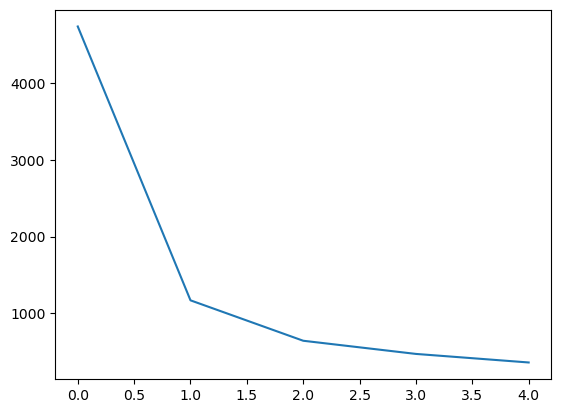

In [72]:
mini_batch_training(x, y, 100, n, 32)

In [25]:
def gradient_accumulation_train(epoch, xs, ys, n):
    losses = []
    epoch_timings = []

    for k in range(epoch):
        start = time.time()

        #zero_grad 
        for p in n.parameters():
            p.grad = 0.0

        total_loss = 0.0 

        #loop for each sample
        for x, ygt_idx in zip(xs, ys):
            #forward pass
            ypred_logits = n(x)

            #backward pass
            l = nll_loss(ypred_logits, ygt_idx)   
            l.backward()                          
            total_loss += l.data    

        # update
        for p in n.parameters():
            p.grad = max(min(p.grad, 1.0), -1.0)  # clip grads
            p.data += -0.01 * p.grad

        end = time.time()
        duration = end - start
        epoch_timings.append(duration)

        print(f"Epoch: {k} | Loss: {total_loss:.4f} | Duration: {duration:.4f}s")
        losses.append(total_loss)  

        #Early Stopping
        if (k%10==0):
            acc=accuracy(x_test, y_test)
            print(f"Accuracy: {acc}")
            if acc>0.90:
                break

    loss_plot(losses)
    return total_loss

In [ ]:
final_loss=train2(200, x_train, y_train, n)

In [ ]:
x = x_test[5]
print(y_test[5])
pred = predict(x)
img = np.array(x).reshape(8,8)
plt.imshow(img)

In [ ]:
draw_dot(final_loss)

In [ ]:
draw_dot(ypred[0][0])